In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from plotly import graph_objects as go

In [195]:
flat_df=pd.read_csv("apartments.csv")
house_df=pd.read_csv("houses.csv")
plot_df=pd.read_csv("plots.csv")

In [196]:
flat_df.drop_duplicates(inplace=True)

## Price(INR in Lakhs)

In [ ]:
def numerical_vs_target_eda(df, numerical_cols, target, use_log=False):

    print("="*60)
    print("NUMERICAL VS TARGET EDA")
    print("="*60)

    y = target

    # Apply log transform if needed
    if use_log:
        df['log_target'] = np.log1p(df[target])
        y = 'log_target'

    # Scatter plots
    for col in numerical_cols:

        if col == target:
            continue

        plt.figure(figsize=(7,5))

        sns.scatterplot(
            x=df[col],
            y=df[y]
        )

        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

    # Correlation
    corr_cols = numerical_cols + [y]

    corr_with_target = (
        df[corr_cols]
        .corr(numeric_only=True)[y]
        .sort_values(ascending=False)
    )

    print("\nCorrelation with Target:")
    print(corr_with_target)


NUMERICAL VS TARGET EDA


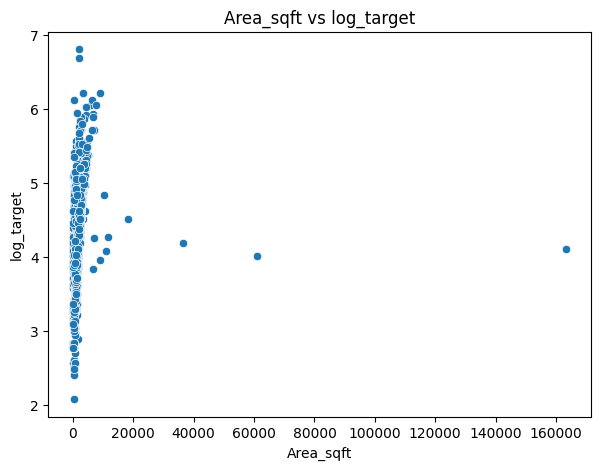

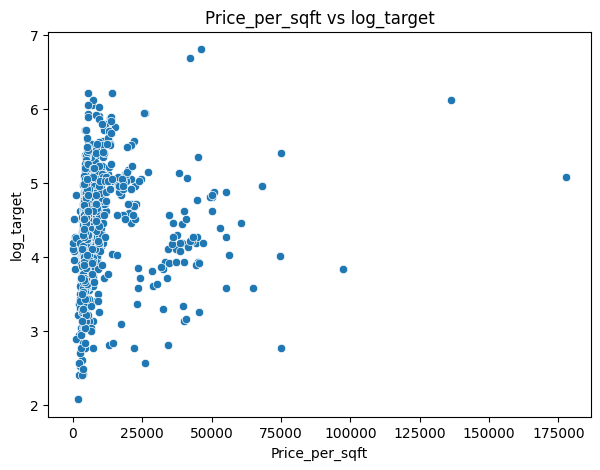

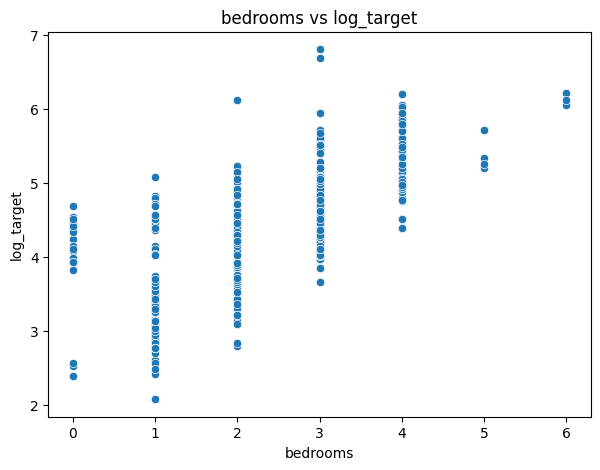

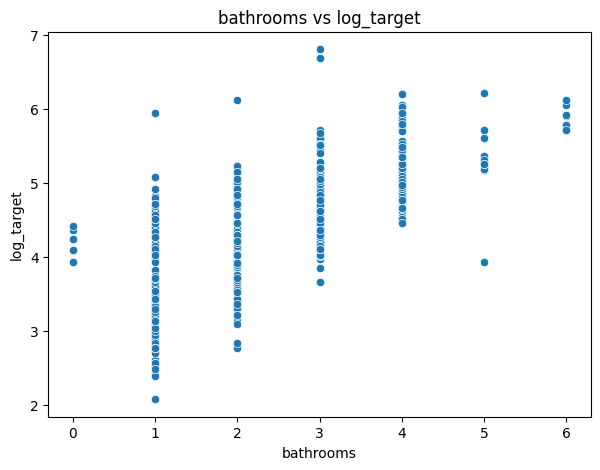

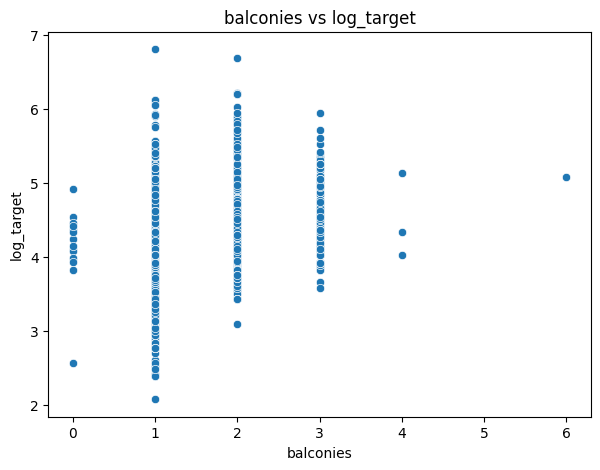

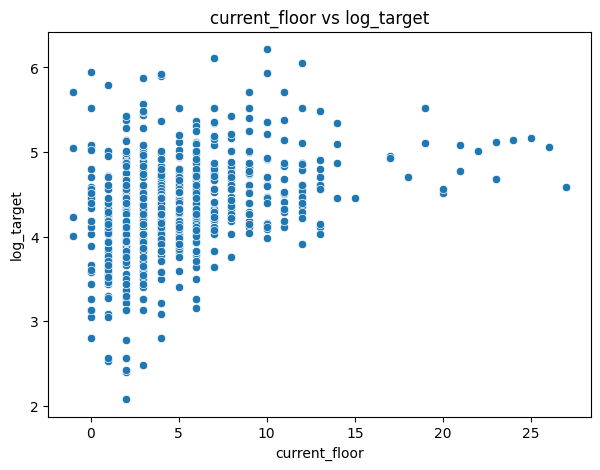

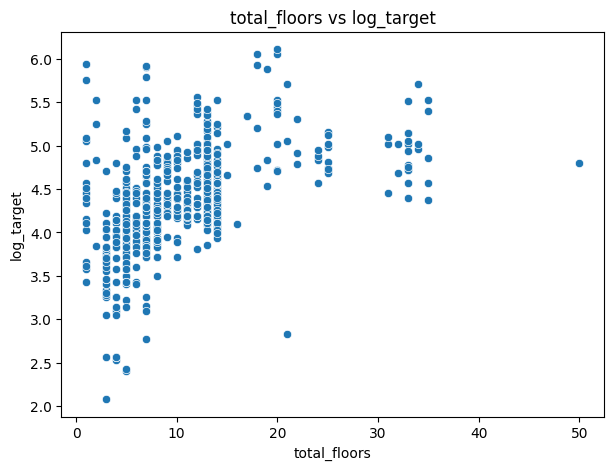

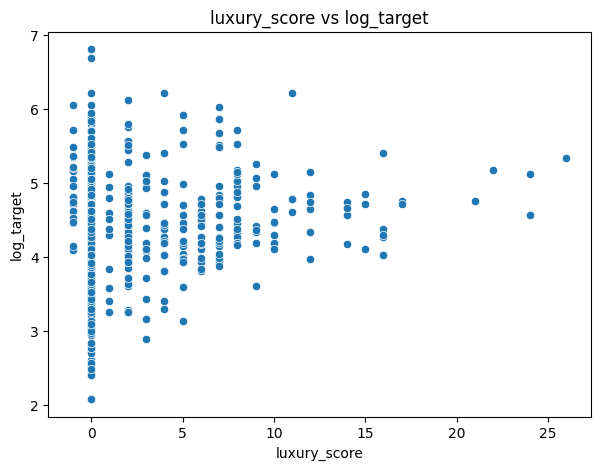

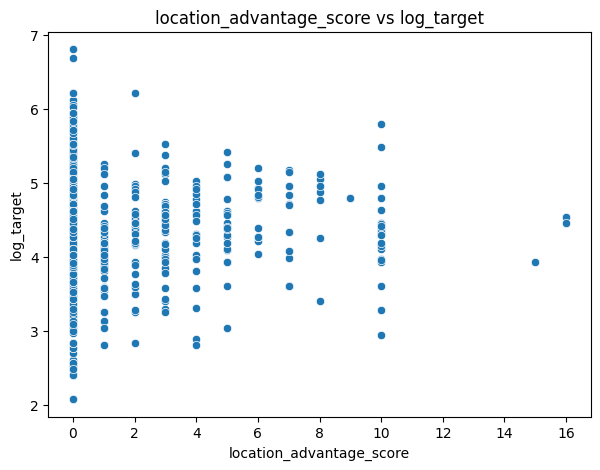


Correlation with Target:
log_target                  1.000000
bedrooms                    0.692348
bathrooms                   0.681695
total_floors                0.489239
current_floor               0.343735
balconies                   0.208102
luxury_score                0.116857
Price_per_sqft              0.115290
Area_sqft                   0.110423
location_advantage_score   -0.006301
Name: log_target, dtype: float64


In [287]:
numerical_cols = [
    'Area_sqft',
    'Price_per_sqft',
    'bedrooms',
    'bathrooms',
    'balconies',
    'current_floor',
    'total_floors',
    'luxury_score',
    'location_advantage_score'
]

target = 'Price (INR in Lakhs)'

numerical_vs_target_eda(flat_df, numerical_cols, target, use_log=True)

In [288]:
def cat_vs_num_eda(df, cat_col, num_col, top_n=10, estimator=np.mean, log_target=None):
    print("="*60)
    print(f"{cat_col} vs {num_col} EDA")
    print("="*60)

    # Determine numeric column to use (optionally log-transformed)
    y_col = num_col
    if log_target is True:
        log_col = f'log_{num_col}'
        df[log_col] = np.log1p(df[num_col])
        y_col = log_col
    elif isinstance(log_target, str) and log_target:
        y_col = log_target

    # Top categories based on frequency
    top_categories = df[cat_col].value_counts().head(top_n).index

    temp_df = df[df[cat_col].isin(top_categories)]

    # Plot
    plt.figure(figsize=(12,6))

    sns.barplot(
        x=cat_col,
        y=y_col,
        data=temp_df,
        estimator=estimator
    )

    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} {cat_col} vs {y_col} ({estimator.__name__})")
    plt.xlabel(cat_col)
    plt.ylabel(y_col)

    plt.show()

In [289]:
cat_cols = ['furnishing_status','Mapped_Area','facing','property_age_bucket','property_type',
            'is_ready_to_move']

furnishing_status vs Price (INR in Lakhs) EDA


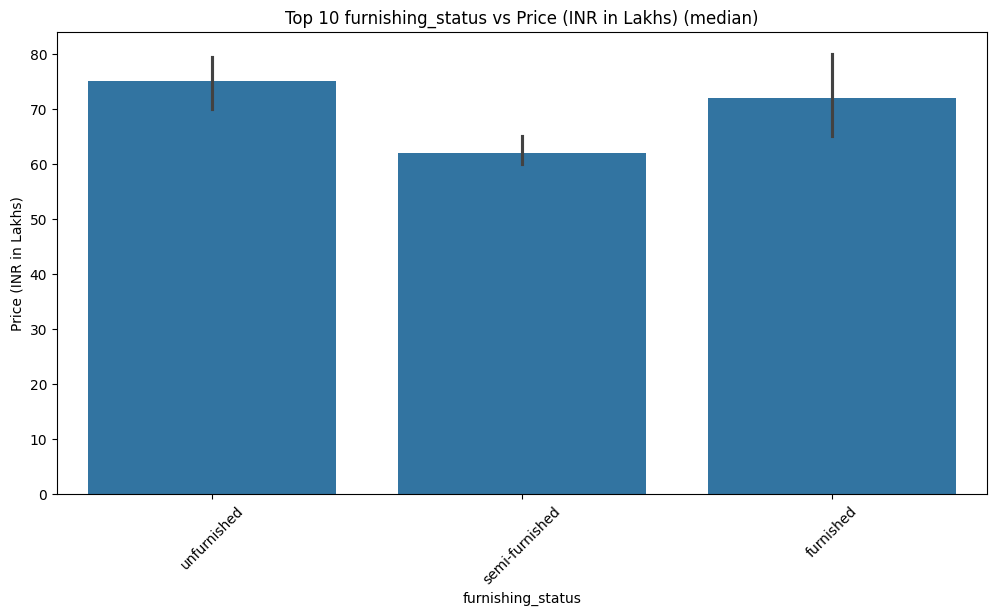

Mapped_Area vs Price (INR in Lakhs) EDA


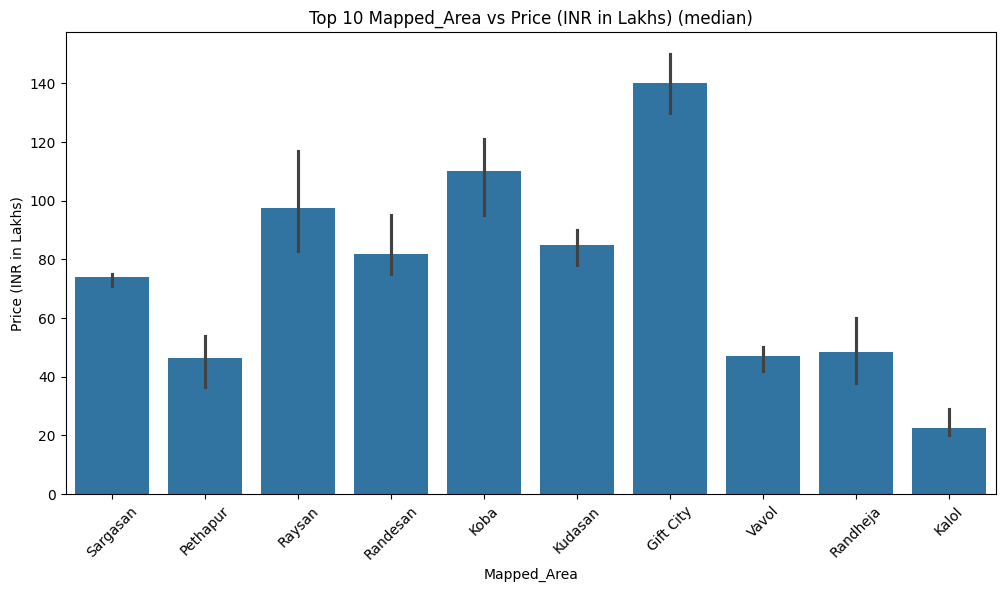

facing vs Price (INR in Lakhs) EDA


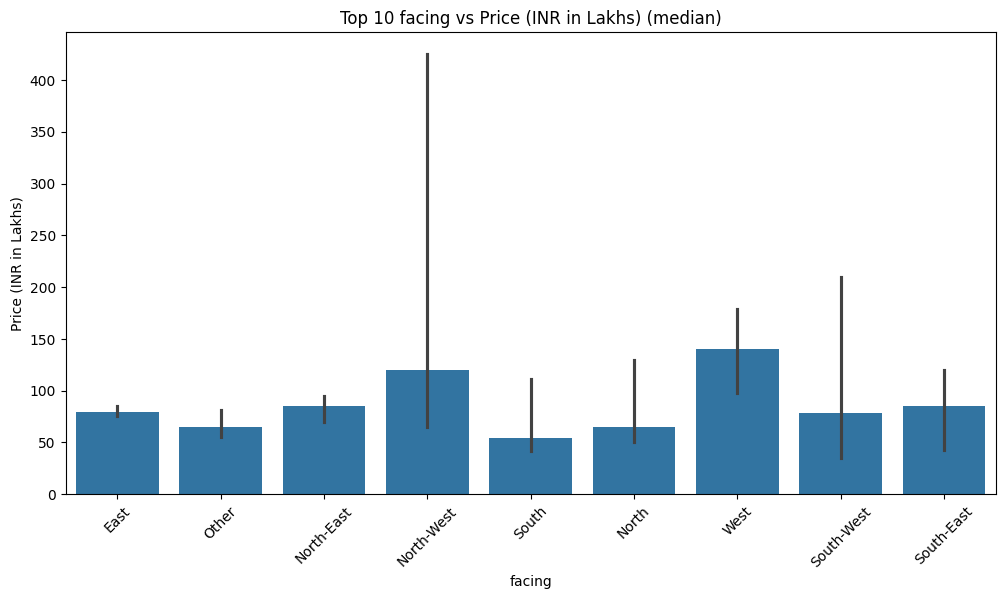

property_age_bucket vs Price (INR in Lakhs) EDA


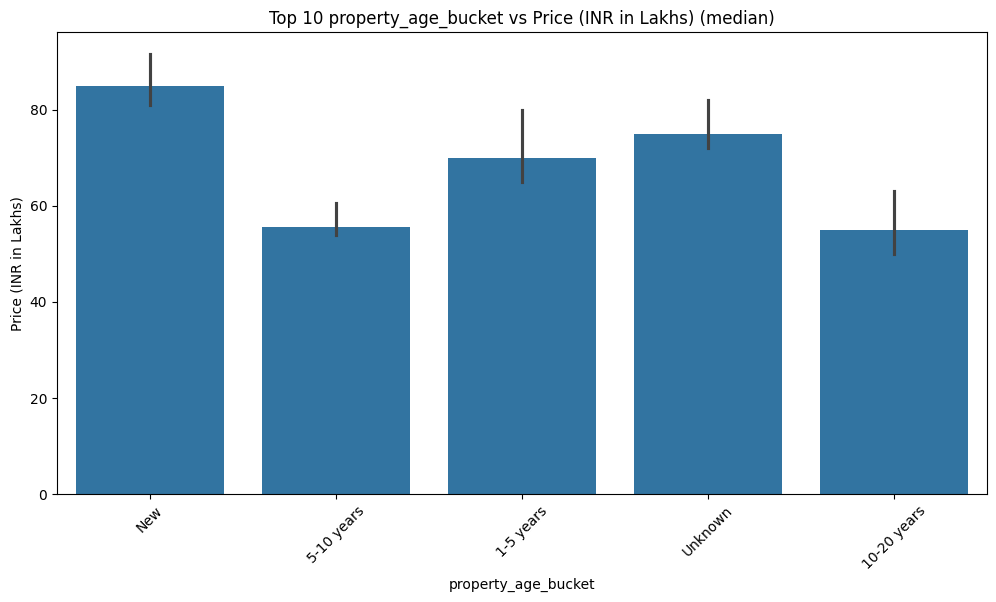

property_type vs Price (INR in Lakhs) EDA


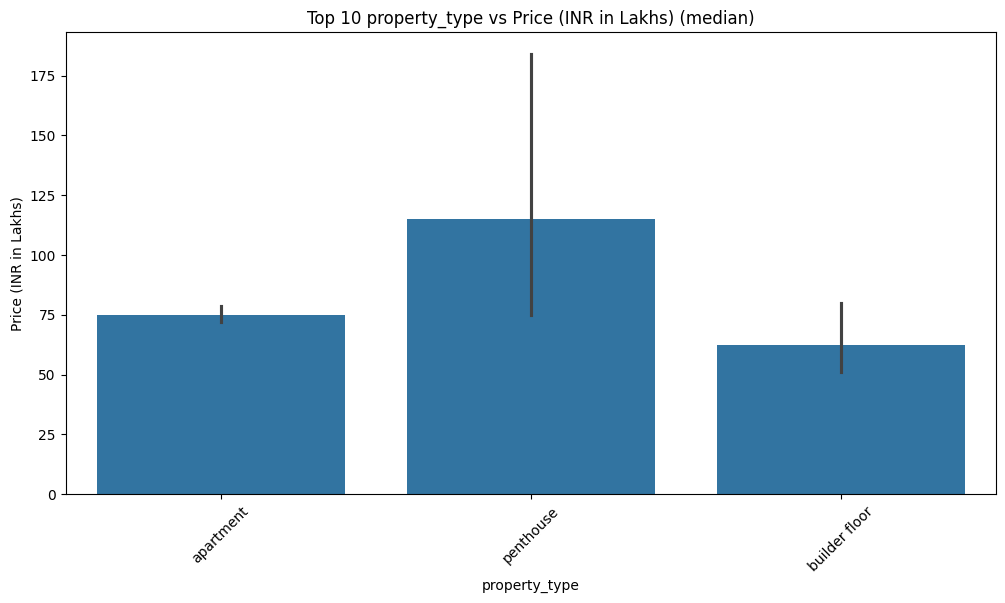

is_ready_to_move vs Price (INR in Lakhs) EDA


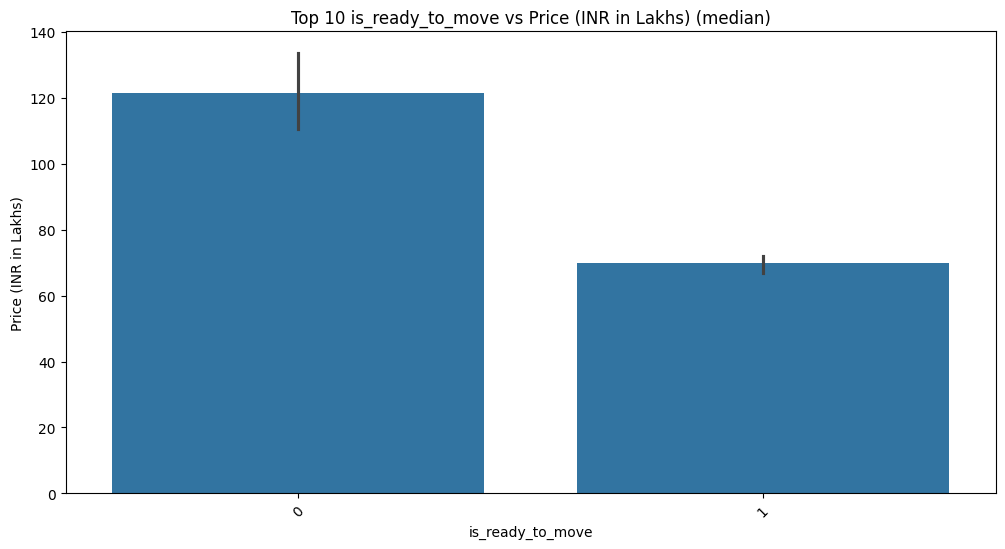

In [290]:
for col in cat_cols:
    cat_vs_num_eda(flat_df, col, target,estimator=np.median)

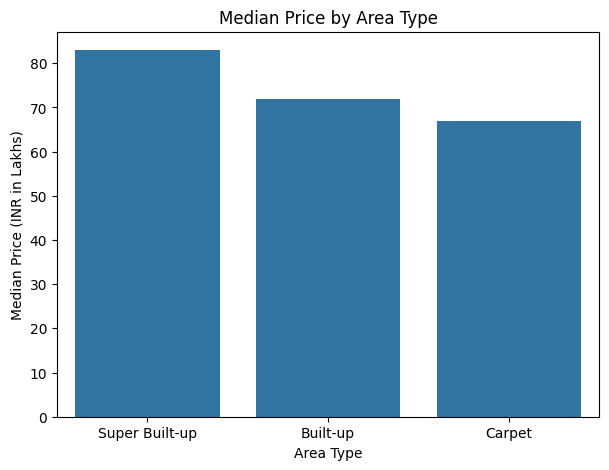

In [291]:
median_prices = pd.Series({
    'Super Built-up': flat_df.loc[
        flat_df['is_super_built_up_area'] == 1,
        'Price (INR in Lakhs)'
    ].median(),

    'Built-up': flat_df.loc[
        flat_df['is_built_up_area'] == 1,
        'Price (INR in Lakhs)'
    ].median(),

    'Carpet': flat_df.loc[
        flat_df['is_carpet_area'] == 1,
        'Price (INR in Lakhs)'
    ].median()
})

plt.figure(figsize=(7,5))

sns.barplot(
    x=median_prices.index,
    y=median_prices.values
)

plt.title('Median Price by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Median Price (INR in Lakhs)')

plt.show()

<Axes: xlabel='bedrooms', ylabel='Area_sqft'>

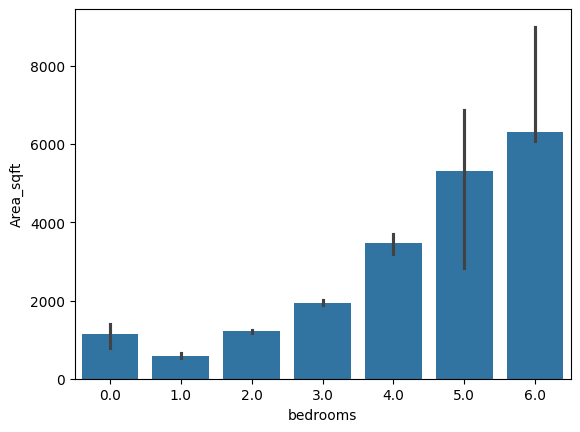

In [292]:
sns.barplot(data=flat_df, x='bedrooms', y='Area_sqft',estimator=np.median)

<Axes: xlabel='bathrooms', ylabel='Area_sqft'>

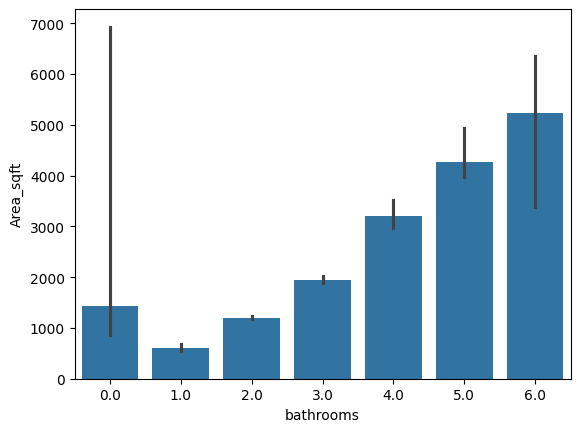

In [293]:
sns.barplot(data=flat_df, x='bathrooms', y='Area_sqft',estimator=np.median)

<Axes: xlabel='bathrooms', ylabel='bedrooms'>

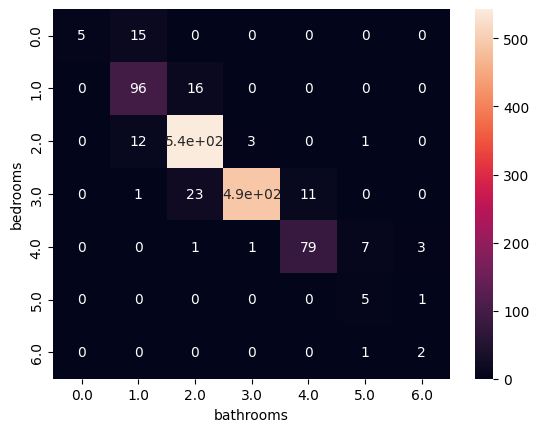

In [294]:
# pd.crosstab(flat_df['bedrooms'], flat_df['bathrooms'])
sns.heatmap(pd.crosstab(flat_df['bedrooms'], flat_df['bathrooms']), annot=True)

<Axes: xlabel='balconies', ylabel='bedrooms'>

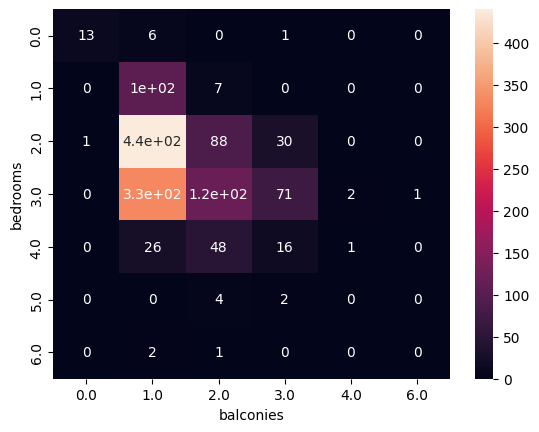

In [295]:
sns.heatmap(pd.crosstab(flat_df['bedrooms'], flat_df['balconies']), annot=True)

<Axes: xlabel='Area_sqft', ylabel='Price_per_sqft'>

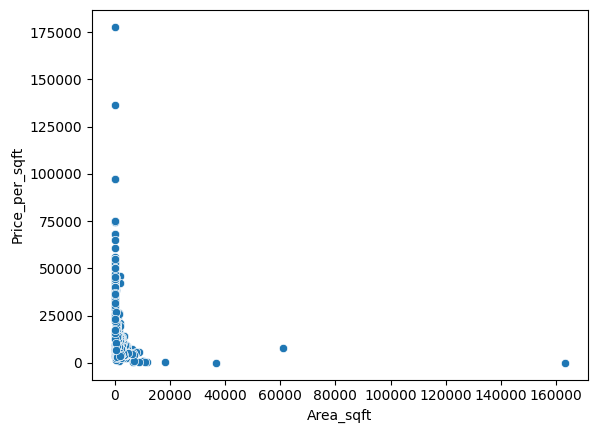

In [296]:
sns.scatterplot(data=flat_df, x='Area_sqft', y='Price_per_sqft')

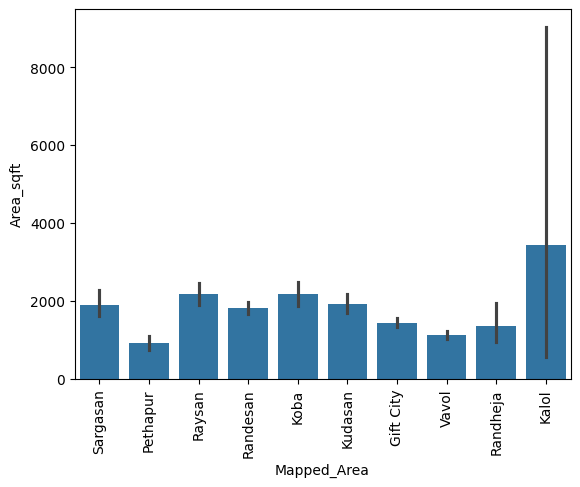

In [297]:
top10 = flat_df['Mapped_Area'].value_counts().head(10).index

sns.barplot(
    data=flat_df[flat_df['Mapped_Area'].isin(top10)],
    x='Mapped_Area',
    y='Area_sqft'
)
plt.xticks(rotation=90)
plt.show()

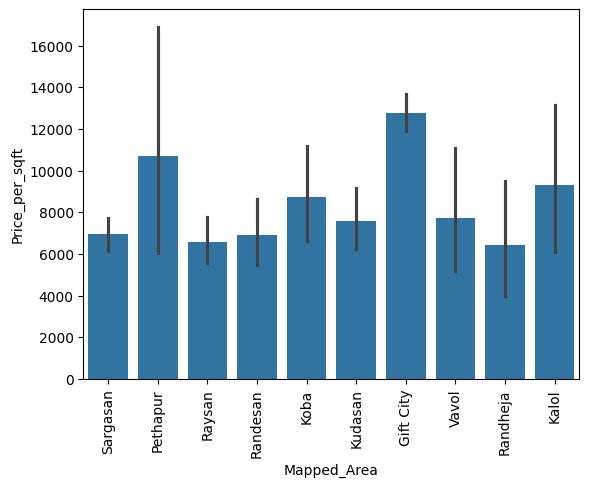

In [298]:
sns.barplot(
    data=flat_df[flat_df['Mapped_Area'].isin(top10)],
    x='Mapped_Area',
    y='Price_per_sqft'
)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='property_type', ylabel='Area_sqft'>

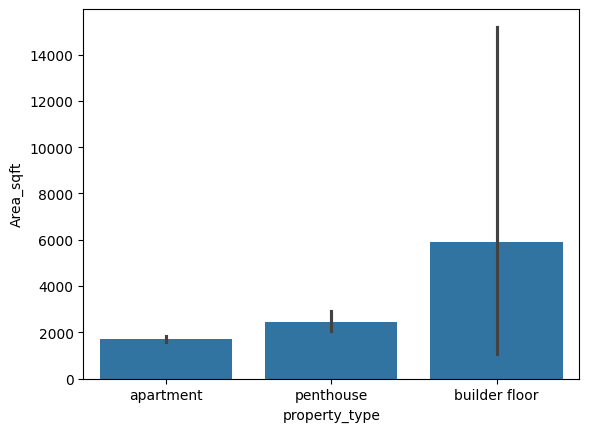

In [299]:
sns.barplot(data=flat_df,
            x='property_type',
            y='Area_sqft')

In [300]:
pd.crosstab(flat_df['property_type'],
            flat_df['bedrooms'])

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0
property_type,,,,,,,
apartment,20,104,538,507,87,6,3
builder floor,0,6,17,13,0,0,0
penthouse,0,2,4,5,4,0,0


<Axes: xlabel='property_age_bucket', ylabel='Area_sqft'>

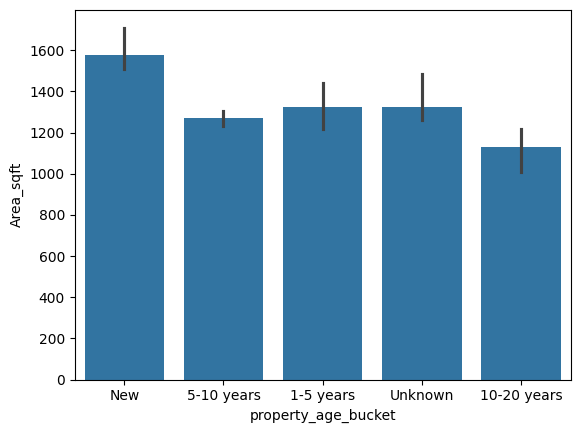

In [303]:
sns.barplot(data=flat_df,
            x='property_age_bucket',
            y='Area_sqft',estimator=np.median)

<Axes: xlabel='property_age_bucket', ylabel='Price_per_sqft'>

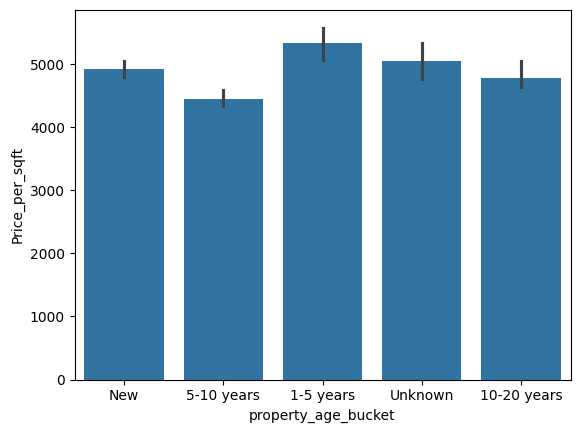

In [306]:
sns.barplot(data=flat_df,
            x='property_age_bucket',
            y='Price_per_sqft',estimator=np.median)

In [311]:
pd.crosstab(flat_df['property_age_bucket'],
            flat_df['property_type'])

property_type,apartment,builder floor,penthouse
property_age_bucket,,,
1-5 years,163,3,0
10-20 years,59,1,0
5-10 years,118,2,0
New,597,20,12
Unknown,330,10,3


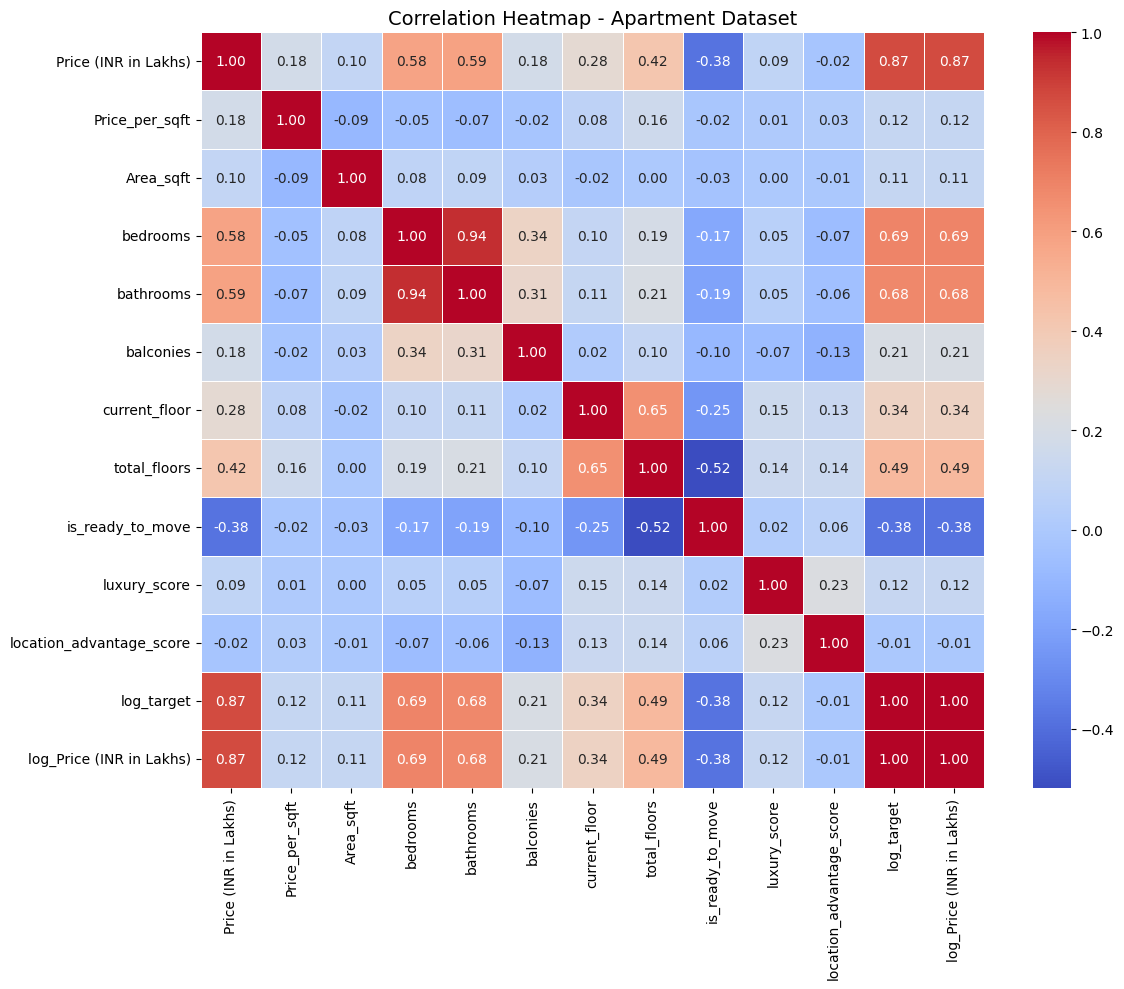

In [319]:
num_cols = flat_df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 10))

# Plot heatmap
sns.heatmap(flat_df[num_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',         
            linewidths=0.5)     

plt.title('Correlation Heatmap - Apartment Dataset', fontsize=14)
plt.tight_layout()             
plt.show()

## Price (INR in Lakhs)

In [322]:
def numerical_vs_target_eda(df, numerical_cols, target, use_log=False):

    print("="*60)
    print("NUMERICAL VS TARGET EDA")
    print("="*60)

    y = target

    # Apply log transform if needed
    if use_log:
        df['log_target'] = np.log1p(df[target])
        y = 'log_target'

    # Scatter plots
    for col in numerical_cols:

        if col == target:
            continue

        plt.figure(figsize=(7,5))

        sns.scatterplot(
            x=df[col],
            y=df[y]
        )

        plt.title(f'{col} vs {y}')
        plt.xlabel(col)
        plt.ylabel(y)
        plt.show()

    # Correlation
    corr_cols = numerical_cols + [y]

    corr_with_target = (
        df[corr_cols]
        .corr(numeric_only=True)[y]
        .sort_values(ascending=False)
    )

    print("\nCorrelation with Target:")
    print(corr_with_target)


NUMERICAL VS TARGET EDA


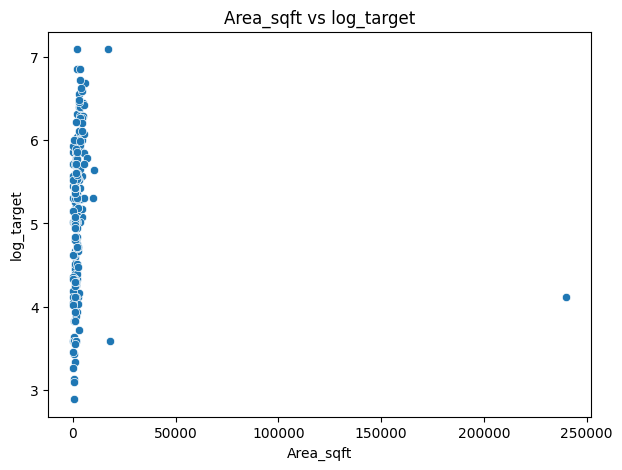

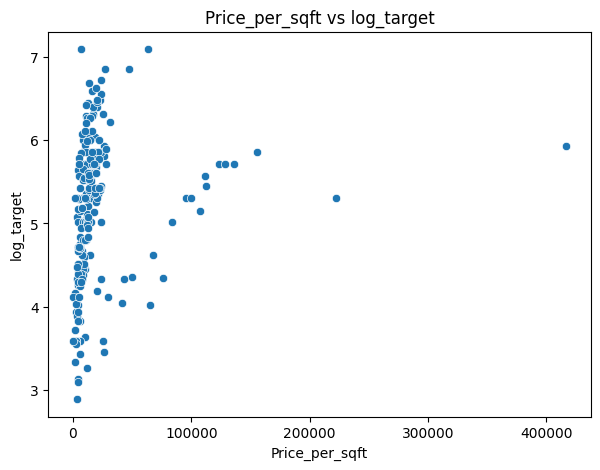

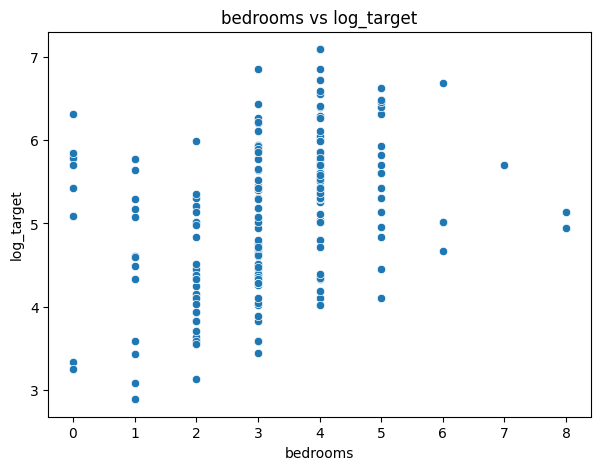

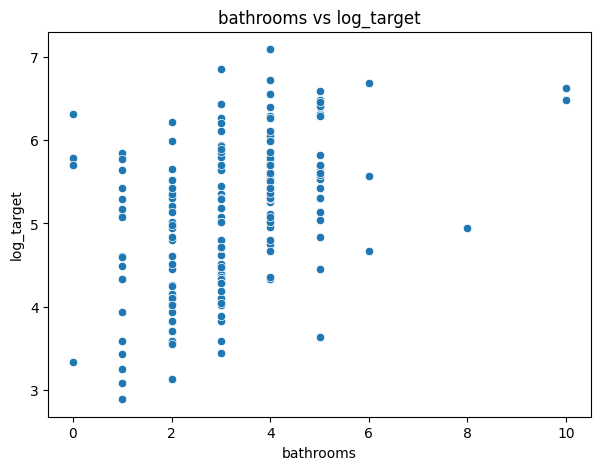

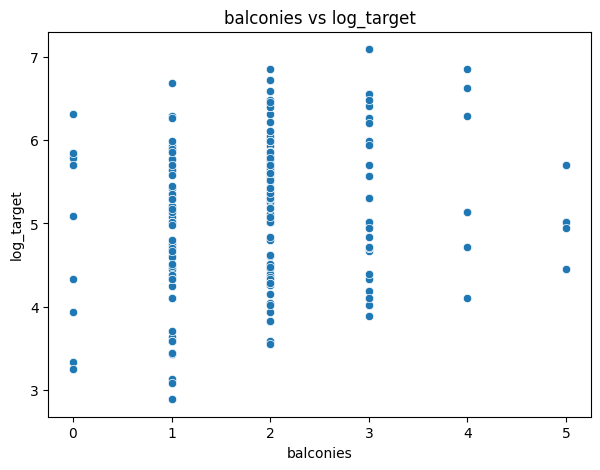

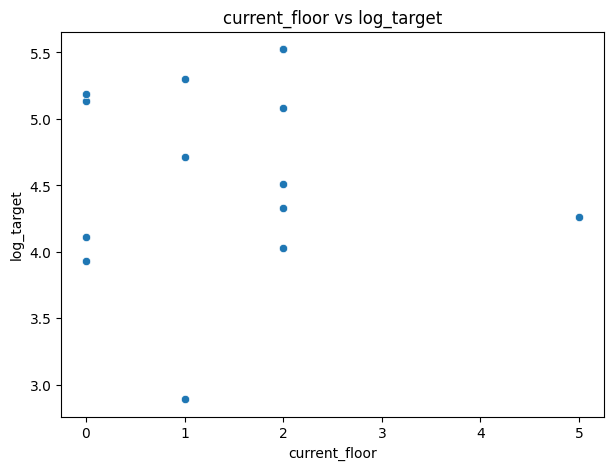

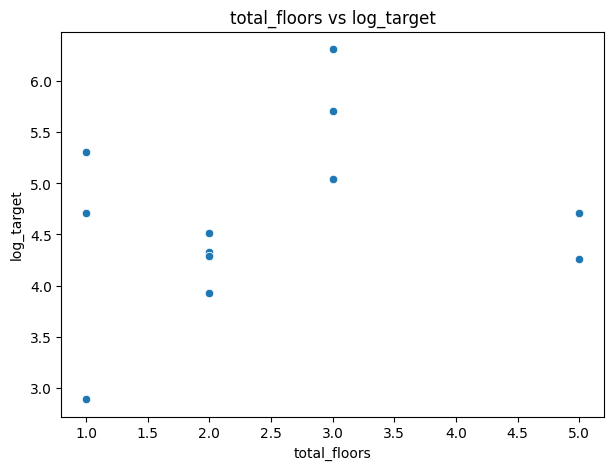

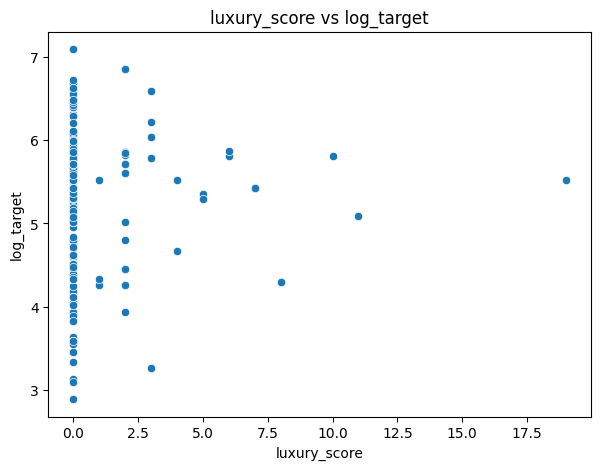

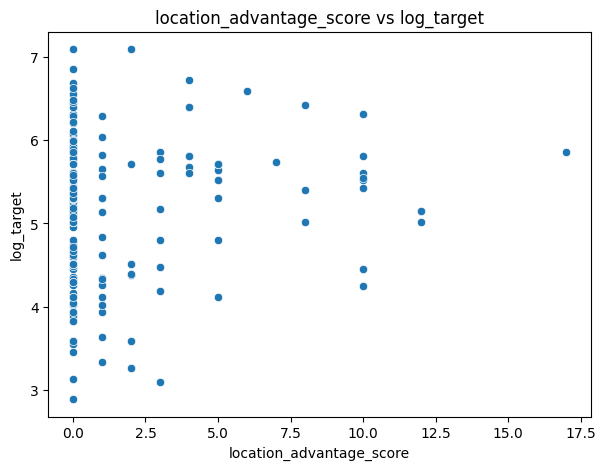


Correlation with Target:
log_target                  1.000000
bathrooms                   0.457691
bedrooms                    0.383639
total_floors                0.240127
Price_per_sqft              0.175979
balconies                   0.153425
location_advantage_score    0.087603
luxury_score                0.051038
current_floor               0.002149
Area_sqft                  -0.039791
Name: log_target, dtype: float64


In [ ]:
numerical_cols = [
    'Area_sqft',
    'Price_per_sqft',
    'bedrooms',
    'bathrooms',
    'balconies',
    'current_floor',
    'total_floors',
    'luxury_score',
    'location_advantage_score'
]

target = 'Price (INR in Lakhs)'

numerical_vs_target_eda(house_df, numerical_cols, target,use_log=True)

In [325]:
def cat_vs_num_eda(df, cat_col, num_col, top_n=10, estimator=np.mean, log_target=None):
    print("="*60)
    print(f"{cat_col} vs {num_col} EDA")
    print("="*60)

    # Determine numeric column to use (optionally log-transformed)
    y_col = num_col
    if log_target is True:
        log_col = f'log_{num_col}'
        df[log_col] = np.log1p(df[num_col])
        y_col = log_col
    elif isinstance(log_target, str) and log_target:
        y_col = log_target

    # Top categories based on frequency
    top_categories = df[cat_col].value_counts().head(top_n).index

    temp_df = df[df[cat_col].isin(top_categories)]

    # Plot
    plt.figure(figsize=(12,6))

    sns.barplot(
        x=cat_col,
        y=y_col,
        data=temp_df,
        estimator=estimator
    )

    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} {cat_col} vs {y_col} ({estimator.__name__})")
    plt.xlabel(cat_col)
    plt.ylabel(y_col)

    plt.show()

In [326]:
cat_cols = ['furnishing_status','Mapped_Area','facing','property_age_bucket','property_type',
            'is_ready_to_move']

furnishing_status vs Price (INR in Lakhs) EDA


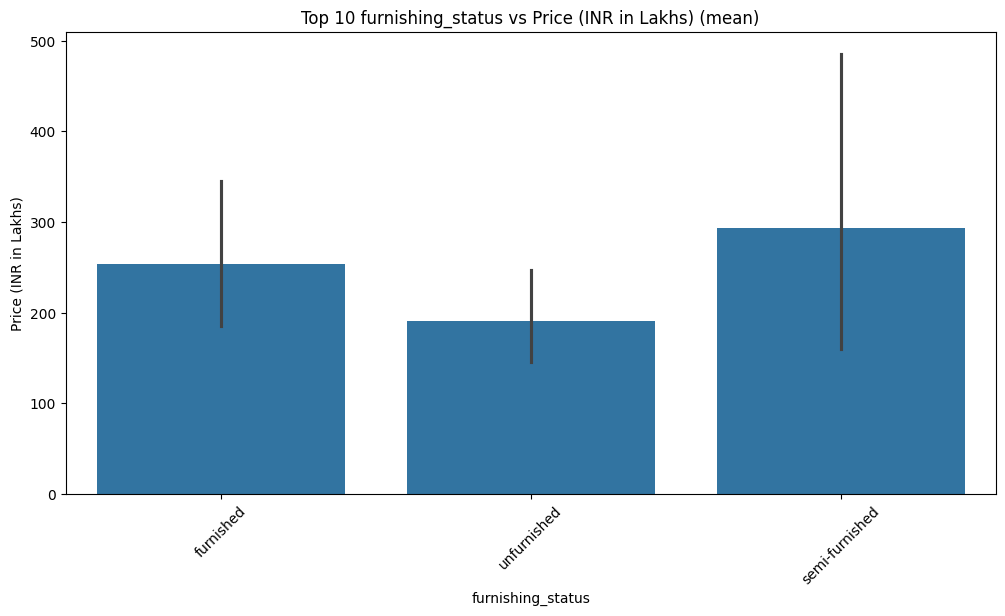

Mapped_Area vs Price (INR in Lakhs) EDA


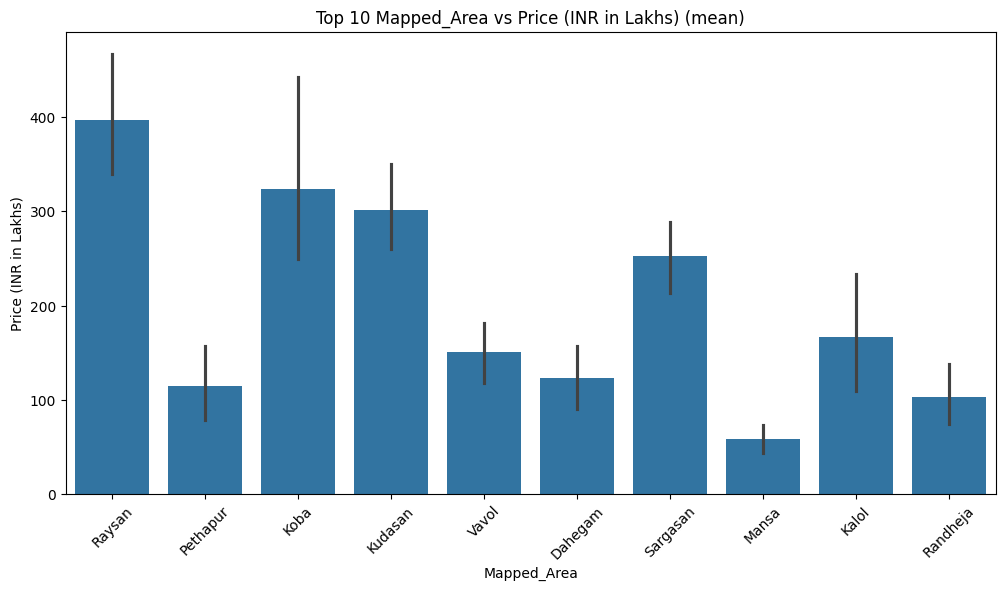

facing vs Price (INR in Lakhs) EDA


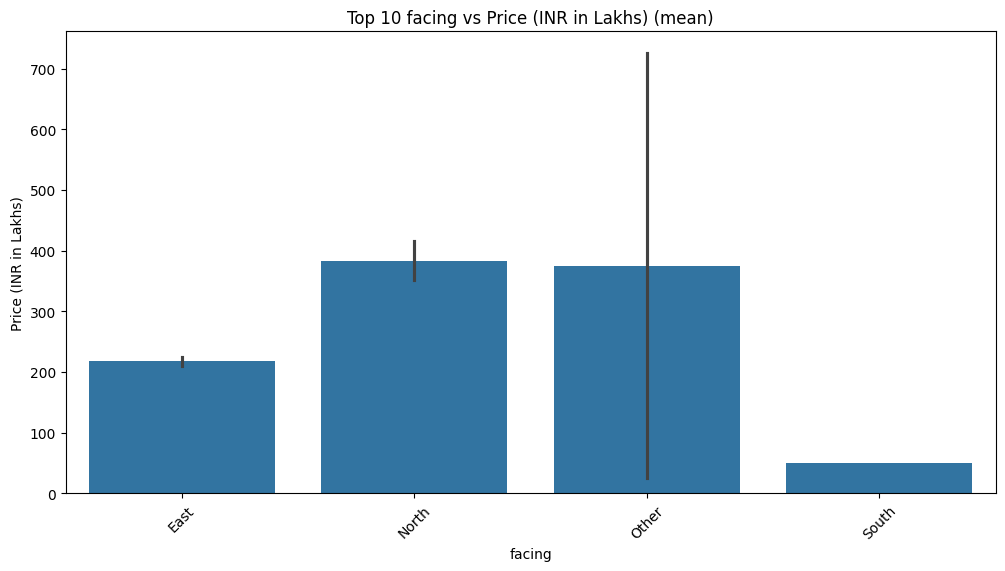

property_age_bucket vs Price (INR in Lakhs) EDA


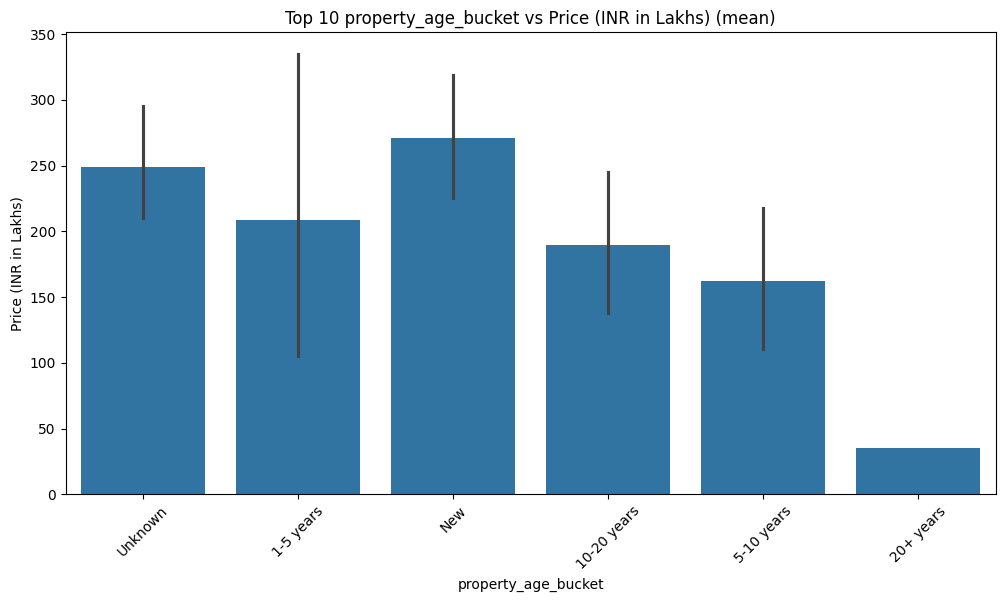

property_type vs Price (INR in Lakhs) EDA


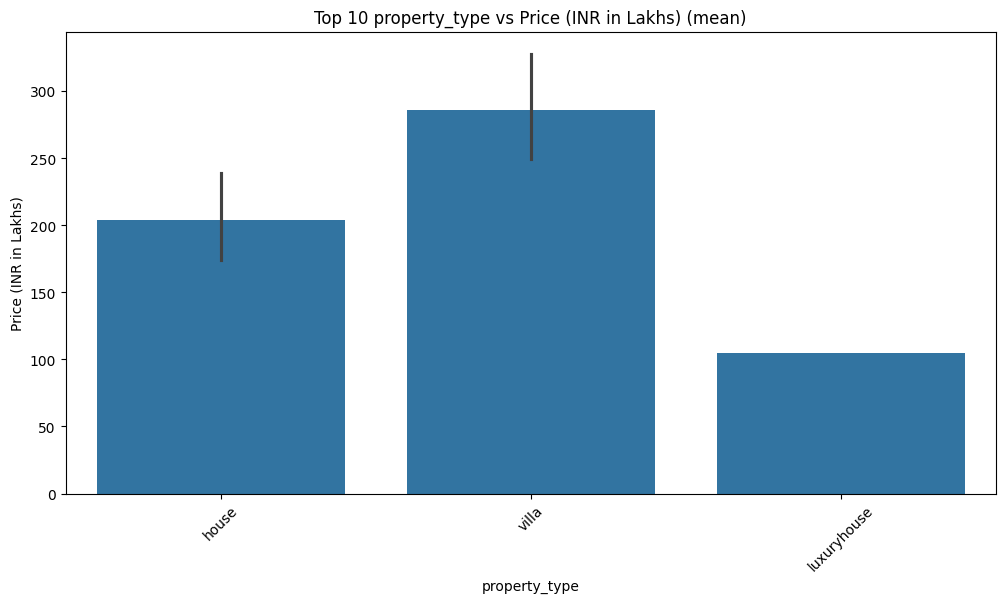

is_ready_to_move vs Price (INR in Lakhs) EDA


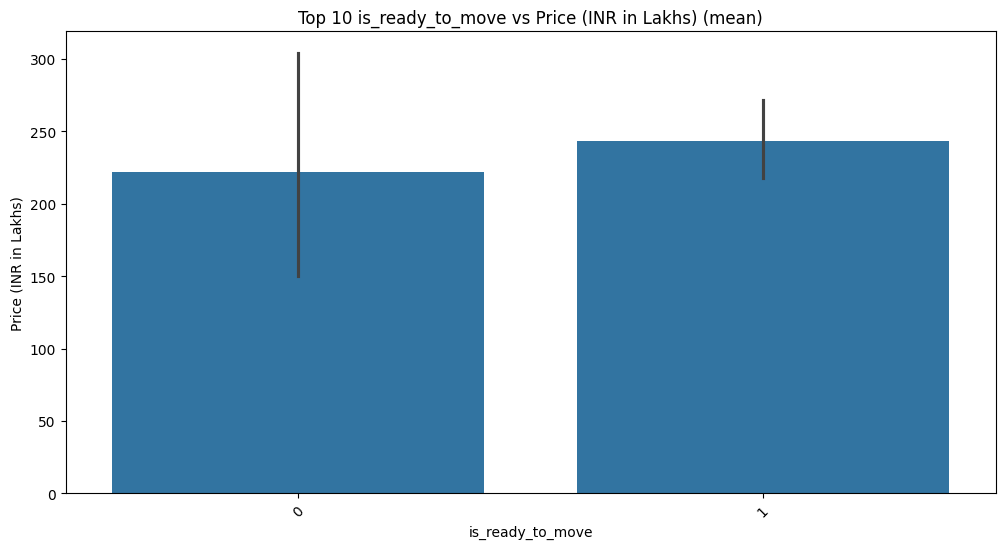

In [330]:
for col in cat_cols:
    cat_vs_num_eda(house_df, col, target)

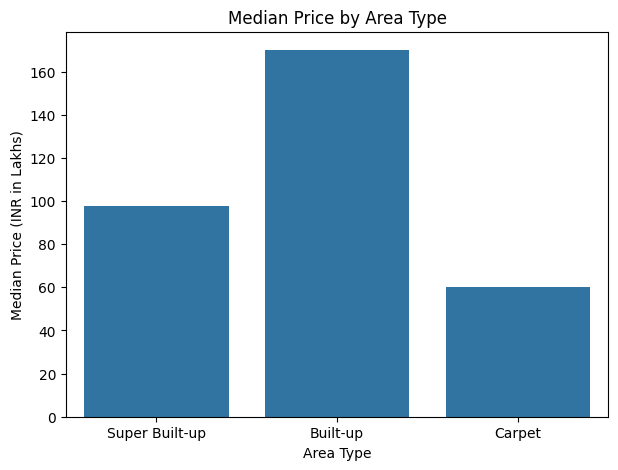

In [333]:
median_prices = pd.Series({
    'Super Built-up': house_df.loc[
        house_df['is_super_built_up_area'] == 1,
        'Price (INR in Lakhs)'
    ].median(),

    'Built-up': house_df.loc[
        house_df['is_built_up_area'] == 1,
        'Price (INR in Lakhs)'
    ].median(),

    'Carpet': house_df.loc[
        house_df['is_carpet_area'] == 1,
        'Price (INR in Lakhs)'
    ].median()
})

plt.figure(figsize=(7,5))

sns.barplot(
    x=median_prices.index,
    y=median_prices.values
)

plt.title('Median Price by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Median Price (INR in Lakhs)')

plt.show()

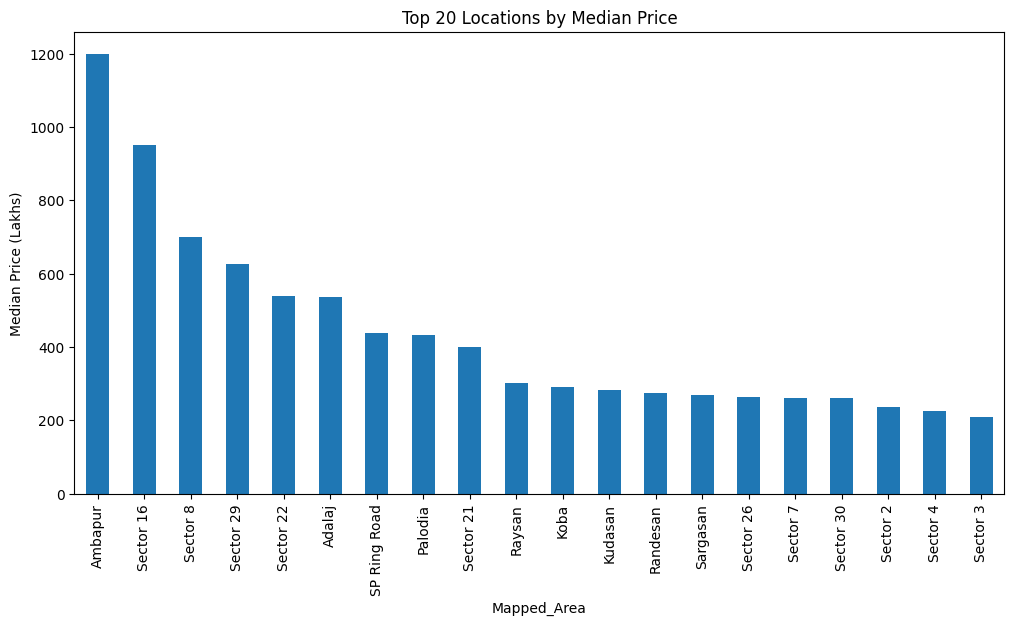

In [337]:
loc_price = (
    house_df.groupby('Mapped_Area')['Price (INR in Lakhs)']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
loc_price.head(20).plot(kind='bar')
plt.title('Top 20 Locations by Median Price')
plt.ylabel('Median Price (Lakhs)')
plt.show()

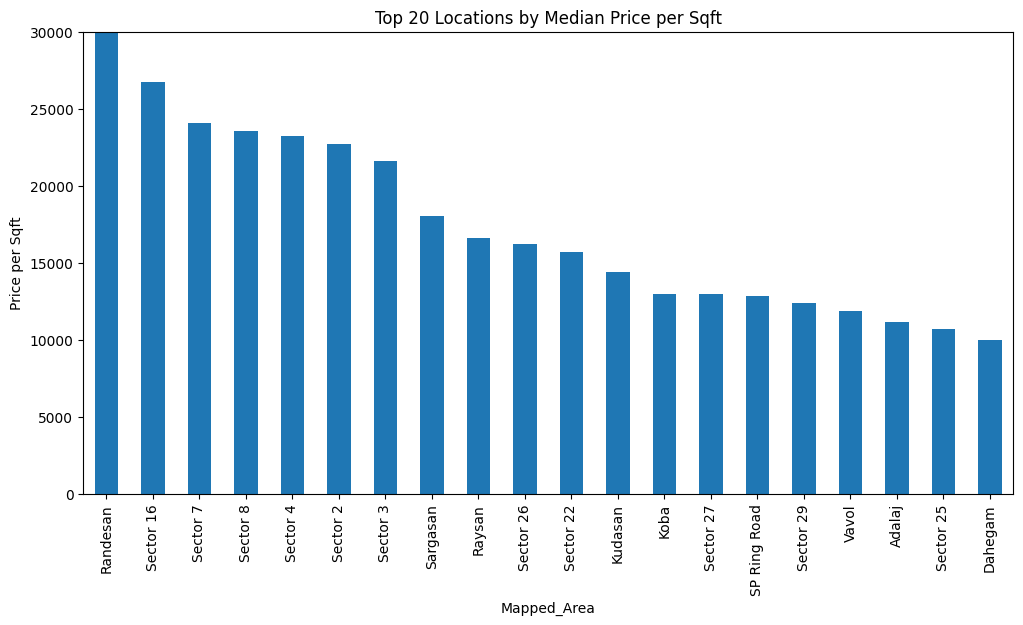

In [339]:
loc_pps = (
    house_df.groupby('Mapped_Area')['Price_per_sqft']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
loc_pps.head(20).plot(kind='bar')
plt.title('Top 20 Locations by Median Price per Sqft')
plt.ylabel('Price per Sqft')
plt.ylim(0,30000)
plt.show()

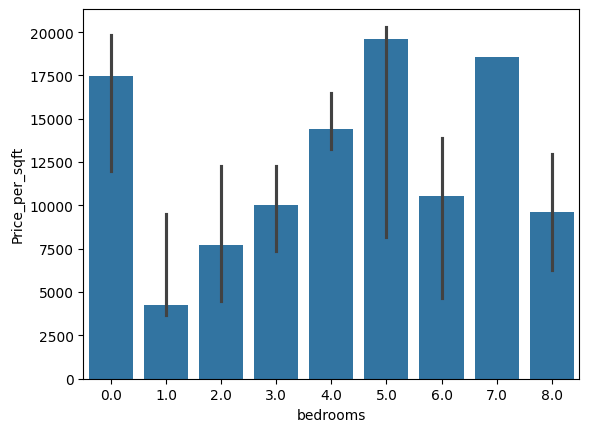

In [343]:
sns.barplot(
    x='bedrooms',
    y='Price_per_sqft',
    data=house_df,
    estimator=np.median
)
plt.show()

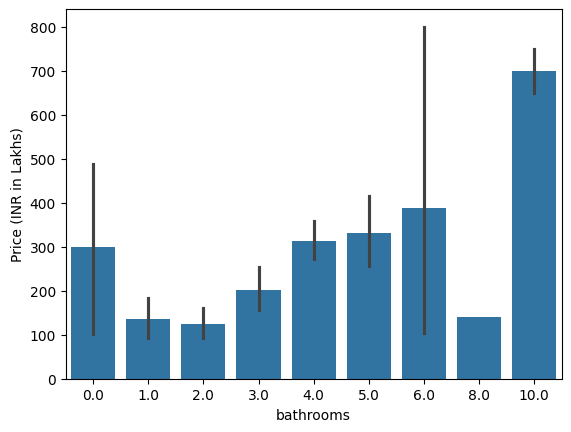

In [348]:
sns.barplot(
    x='bathrooms',
    y='Price (INR in Lakhs)',
    data=house_df,
    
)
plt.show()

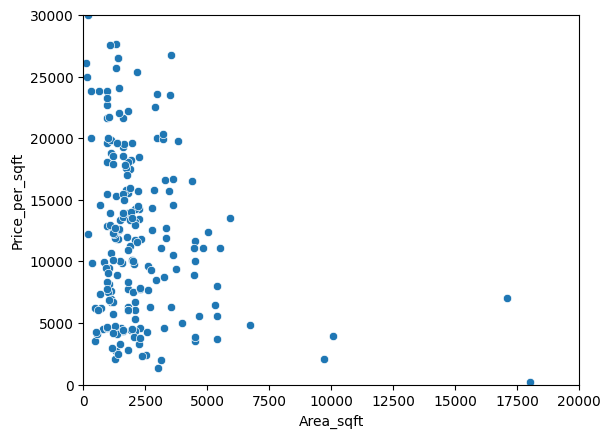

In [351]:
sns.scatterplot(
    x='Area_sqft',
    y='Price_per_sqft',
    data=house_df
)

plt.xlim(0,20000)
plt.ylim(0,30000)
plt.show()

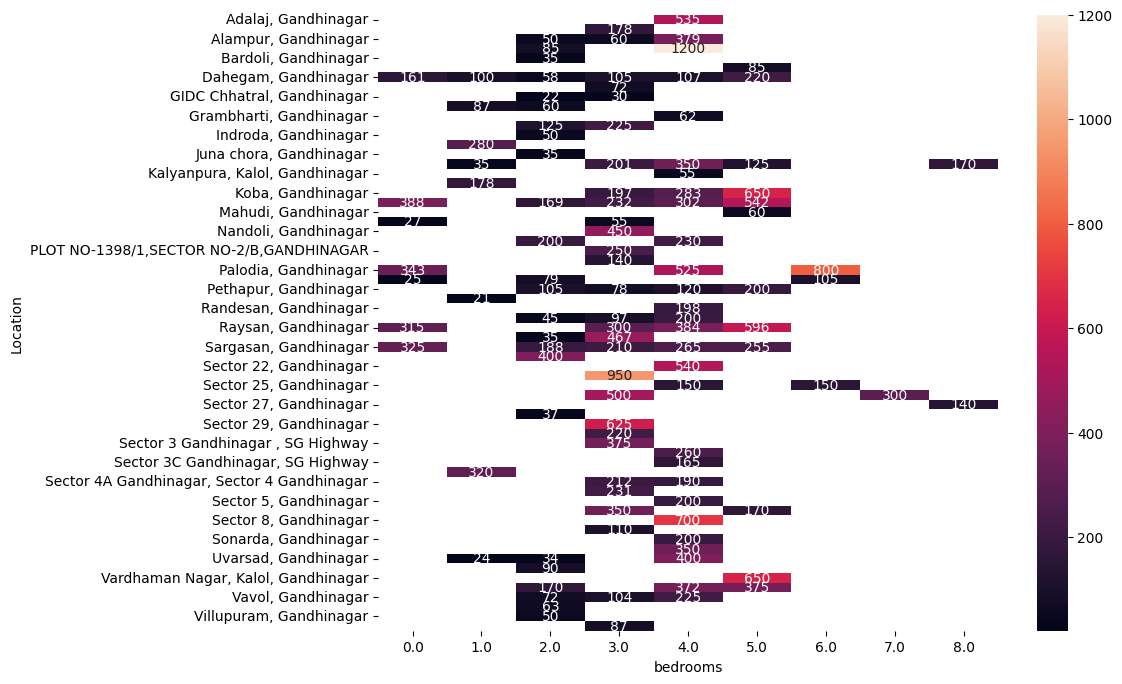

In [354]:
pivot = house_df.pivot_table(
    values='Price (INR in Lakhs)',
    index='Location',
    columns='bedrooms',
    aggfunc='mean'
)

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, fmt='.0f')
plt.show()

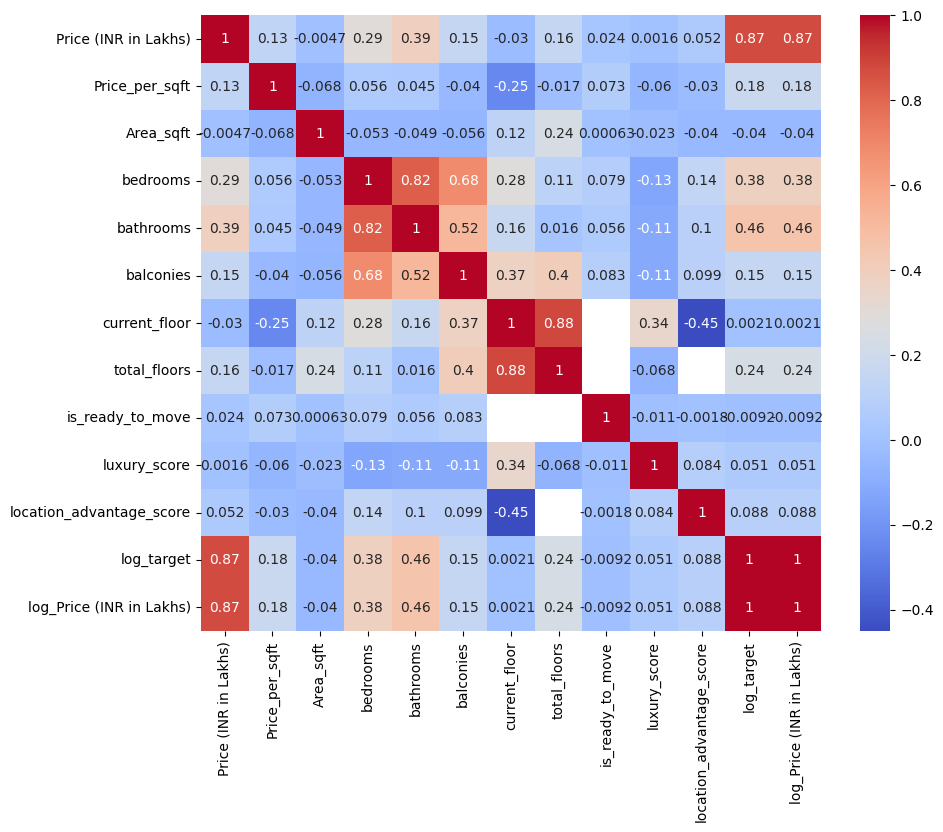

In [355]:
num_cols = house_df.select_dtypes(
    include=['int64','float64']
).columns

corr = house_df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

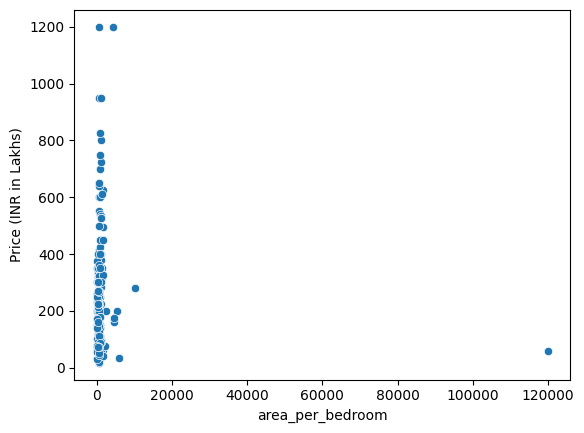

In [356]:
house_df['area_per_bedroom'] = (
    house_df['Area_sqft'] /
    house_df['bedrooms']
)

sns.scatterplot(
    x='area_per_bedroom',
    y='Price (INR in Lakhs)',
    data=house_df
)

plt.show()